<a href="https://colab.research.google.com/github/luciestrada/Lab-Biose-ales-V4-6_Lucianas-/blob/main/pr%C3%A1ctica3_se%C3%B1ales_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Práctica 3 – Parte 2**
**Análisis de Señales de EEG para Imaginería Motora**


In [1]:
!pip install mne

---
A continuación se hace la descarga de los datos de los primeros 10 sujetos de la base de datos. Los runs utlizados son **4,8,12** que estos corresponden a las TASK 2, correspondientes a la imagenería motora de la mano izquierda y derecha.



In [2]:
import mne
from mne.datasets import eegbci
from google.colab import drive

# Montar Google Drive y guardar en carpeta
drive.mount('/content/drive')
RUTA_DRIVE = '/content/drive/MyDrive/EEG_data/MNE-eegbci-data'

# Sujetos y runs
SUJETOS = list(range(1, 11))   # Sujetos 1 al 10
RUNS_MI = [4, 8, 12]

for sujeto in SUJETOS:
    rutas = eegbci.load_data(sujeto, runs=RUNS_MI, path=RUTA_DRIVE, update_path=False)
    print(f'  Sujeto {sujeto:02d}:')

print('Listo')

Mounted at /content/drive


Download complete in 31s (7.4 MB)
  Sujeto 01:


Download complete in 29s (7.3 MB)
  Sujeto 02:


Download complete in 29s (7.4 MB)
  Sujeto 03:


Download complete in 29s (7.3 MB)
  Sujeto 04:


...

Download complete in 29s (7.3 MB)
  Sujeto 06:


Download complete in 29s (7.4 MB)
  Sujeto 07:


Download complete in 29s (7.3 MB)
  Sujeto 08:


Download complete in 29s (7.3 MB)
  Sujeto 09:


Download complete in 32s (7.3 MB)
  Sujeto 10:
Listo


---
Necesitamos saber como es la estructura del contenido de la base de datos, por ende miramos los canales y las anotaciones, para poder discriminar la información.

In [3]:
import mne
from mne.datasets import eegbci

RUTA_DRIVE = '/content/drive/MyDrive/EEG_data/MNE-eegbci-data'

# Cargar solo el run 4 del sujeto 1
rutas = eegbci.load_data(1, runs=[4], path=RUTA_DRIVE, update_path=False)
raw   = mne.io.read_raw_edf(rutas[0], preload=True)

# Estandarizamos nombres al sistema 10-20, y seleccionamos solo los de EEG
eegbci.standardize(raw)
raw.pick_types(eeg=True, exclude='bads')

print(raw)
print()
print(raw.info)

#INFORMACIÓN DE COMO ESTÁ LA BASE DE DATOS

# Canales
print('\n── Canales disponibles ──')
print(raw.ch_names)
print(f'Total: {len(raw.ch_names)} canales')

# Anotaciones
print('\n── Anotaciones del archivo ──')
print(raw.annotations)

# OBSERVAR ESTRUCUTRUA(mapa)
eventos, mapa_eventos = mne.events_from_annotations(raw)
print('\n── Mapa de eventos ──')
print(mapa_eventos) # T0 = reposo | T1 = Mano Izquierda | T2 = Mano Derecha

print('\n── Primeros 15 eventos ──')
print('  [muestra_inicio, 0, código_evento]')
print(eventos[:15])

Extracting EDF parameters from /content/drive/MyDrive/EEG_data/MNE-eegbci-data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

<Info | 8 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

── Canales disponibles ──
['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4',

**INFORMACIÓN DE LA BASE DE DATOS**

*   Canales: 64
*   Frecuencia de muestreo: 160 Hz

 Cada archivo tiene **3 tipos de eventos**

 *  T0 = reposo
 *  T1 = imaginería mano izquierda
 *  T2 = imaginería mano derecha

El archivo viene sin filtrar (highpass: 0 Hz, lowpass: 80 Hz).









# **1. Cálculo del RMS**


Un electroencefalograma (EEG) es un dispositivo que registra la actividad eléctrica del cerebro de manera no invasiva, permitiendo capturar las oscilaciones neuronales asociadas a distintos estados cognitivos y motores. La interpretación de estas señales ha impulsado el desarrollo de la interfaz cerebro-computadora (BCI).

Las señales EEG son inherentemente ruidosas, captan no solo la actividad cerebral, sino también señales de otras fuentes como el movimiento muscular, ocular, cardiaco o red electrica, y un filtro ayuda a atenuar estas frecuencias no deseadas  *(Saibene et al., 2023)*. Esto es debido a que estos ruidos ocupan una banda de frecuencia distinta y podrían superponerse en las señales cerebrales de interés; por ende es indispensable el filtrado de estas señales EEG.

En este caso la señal está cruda, por ende es necesario la creación de un filtro en el procesamiento de señales EEG, especialmente en el contexto de la imaginería motora es fundamental.


Para el filtrado de las señales EEG **utilizamos un filtro pasa bandas de 8 - 30 Hz** como etapa de **preprocesamiento**. Este rango de frecuencia fue seleccionado con base en su relevancia neurofisiológica para las tareas de las imágenes motoras que comprende la **banda mu (8-12 Hz) y la banda beta (13-30 Hz)**, que son los ritmos cerebrales más fuertemente modulados durante la imaginación de movimientos *(Singh et al., 2021).*


Las ondas Mu son un tipo específico de ritmo cerebral de 8-13 Hz que se origina en la corteza sensoriomotor y está íntimamente relacionado con la actividad motora y la planificación del movimiento *(Marper, s. f.)*.

Las ondas beta en la imaginaria motora son un tipo de actividad cerebral que se asocia con el movimiento voluntario *(Fisiología de la Actividad Eléctrica del Cerebro: Electroencefalografía | FISIOLOGÍA, s. f.)* .

Ambas bandas, al estar funcionalmente relacionadas con el sistema sensoriomotor, proporcionan información complementaria sobre la intención y ejecución (o imaginería) del movimiento.

---

Las muestras se deben segmentar:

*  T1 = izquierda  --> C1= hemisferio derecho
*  T2 = derecha    --> C3= mano derecha

* Mano izquierda → hemisferio derecho
* Mano derecha → hemisferio izquierdo

Para poder analizar: **RMS(T1) vs RMS(T2)**

In [31]:
import numpy as np
import mne
from mne.datasets import eegbci
import warnings
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

RUTA_DRIVE = '/content/drive/MyDrive/EEG_data/MNE-eegbci-data'
SUJETOS    = list(range(1, 11))
RUNS_MI    = [4, 8, 12]
TMIN       = 0.0   # inicio de la época
TMAX       = 3.0   # fin de la época --> SEGÚN LA BASE DE DATOS


def cargar_epochs_sujeto(sujeto, ruta, runs, tmin, tmax):

    rutas_edf = eegbci.load_data(sujeto, runs=runs, path=ruta, update_path=False)

    # Leer cada run
    raws = [mne.io.read_raw_edf(r, preload=True) for r in rutas_edf]
    raw  = mne.concatenate_raws(raws)

    # Estandarizar nombres
    eegbci.standardize(raw)

    # Filtro de banda
    raw.filter(8.0, 30.0, fir_design='firwin')  # BANDA MU Y BETHA

    # Extraer eventos
    eventos, mapa_eventos = mne.events_from_annotations(raw)
    id_eventos = {'T1': mapa_eventos['T1'], 'T2': mapa_eventos['T2']}

    # Segmentar en épocas
    epochs = mne.Epochs(
        raw, eventos,
        event_id=id_eventos,
        tmin=tmin, tmax=tmax,
        baseline=None,
        preload=True
    )

    return epochs['T1'], epochs['T2'], epochs.ch_names

#función que reciba una señal de múltiples canales y épocas
def calcular_rms_sujeto(epochs):
    data = epochs.get_data()   # (n_epocas, n_canales, n_muestras)

# "calcular el RMS para cada época de cada canal de forma individual sobre el eje del tiempo"
    rms_por_epoca = np.sqrt(np.mean(data ** 2, axis=-1))   # (n_epocas, n_canales)

#"promediar estos valores a través de todas las épocas para obtener un valor representativo del sujeto por cada canal"
    rms_promedio = np.mean(rms_por_epoca, axis=0)
    return rms_promedio

registros_izq = {}
registros_der = {}
canales_ref   = None

for sujeto in SUJETOS:
    print(f'Procesando Sujeto {sujeto:02d}...', end=' ')
    try:
        ep_izq, ep_der, ch_names = cargar_epochs_sujeto(
            sujeto, RUTA_DRIVE, RUNS_MI, TMIN, TMAX
        )
        if canales_ref is None:
            canales_ref = ch_names

        rms_izq = calcular_rms_sujeto(ep_izq)
        rms_der = calcular_rms_sujeto(ep_der)

        registros_izq[f'S{sujeto:03d}'] = dict(zip(ch_names, rms_izq))
        registros_der[f'S{sujeto:03d}'] = dict(zip(ch_names, rms_der))

        print(f'OK  ({len(ep_izq)} épocas T1 | {len(ep_der)} épocas T2)')
    except Exception as e:
        print(f'ERROR: {e}')

print(f'\nTotal canales: {len(canales_ref)}')
print('RMS')

Procesando Sujeto 01... OK  (23 épocas T1 | 22 épocas T2)
Procesando Sujeto 02... OK  (23 épocas T1 | 22 épocas T2)
Procesando Sujeto 03... OK  (23 épocas T1 | 22 épocas T2)
Procesando Sujeto 04... OK  (23 épocas T1 | 22 épocas T2)
Procesando Sujeto 05... OK  (21 épocas T1 | 24 épocas T2)
Procesando Sujeto 06... OK  (24 épocas T1 | 21 épocas T2)
Procesando Sujeto 07... OK  (23 épocas T1 | 22 épocas T2)
Procesando Sujeto 08... OK  (22 épocas T1 | 23 épocas T2)
Procesando Sujeto 09... OK  (24 épocas T1 | 21 épocas T2)
Procesando Sujeto 10... OK  (24 épocas T1 | 21 épocas T2)

Total canales: 64
RMS


---
#**2. Construcción de la Base de Datos Poblacional**

* **Filas:** cada sujeto (S001 – S010)
* **Columnas:** todos los canales del archivo--> NOMBRES DE LOS CANALES (64 canales)
* **Cada Celda:** valor RMS promedio por canal



In [28]:
import pandas as pd

df_izquierda = pd.DataFrame.from_dict(registros_izq, orient='index')[canales_ref]
df_derecha   = pd.DataFrame.from_dict(registros_der, orient='index')[canales_ref]

print('── DataFrame RMS – Mano Izquierda (T1) ──')
print(f'Dimensiones: {df_izquierda.shape}  (sujetos × canales)')
print(df_izquierda)

print('\n── DataFrame RMS – Mano Derecha (T2) ──')
print(f'Dimensiones: {df_derecha.shape}  (sujetos × canales)')
print(df_derecha)

── DataFrame RMS – Mano Izquierda (T1) ──
Dimensiones: (10, 64)  (sujetos × canales)
           FC5       FC3       FC1       FCz       FC2       FC4       FC6        C5        C3        C1  ...        P8  \
S001  0.000014  0.000015  0.000015  0.000015  0.000014  0.000012  0.000010  0.000014  0.000015  0.000015  ...  0.000012   
S002  0.000007  0.000009  0.000010  0.000010  0.000009  0.000008  0.000007  0.000007  0.000009  0.000009  ...  0.000006   
S003  0.000016  0.000015  0.000015  0.000015  0.000015  0.000012  0.000012  0.000015  0.000015  0.000016  ...  0.000013   
S004  0.000006  0.000006  0.000005  0.000005  0.000005  0.000005  0.000005  0.000005  0.000005  0.000005  ...  0.000004   
S005  0.000012  0.000007  0.000007  0.000008  0.000008  0.000007  0.000007  0.000007  0.000007  0.000007  ...  0.000007   
S006  0.000006  0.000005  0.000005  0.000005  0.000005  0.000005  0.000005  0.000006  0.000006  0.000005  ...  0.000003   
S007  0.000013  0.000014  0.000014  0.000012  0.000013

Los valores de RMS obtenidos se encuentran en el **rango esperado para señales EEG filtradas en banda mu (8–13 Hz), del orden de 10⁻⁵ V**.


Adicionalmente se observa alta variabilidad inter-sujeto, lo cual es una característica inherente de las señales EEG. Esta variabilidad se refiere a las diferencias que pueden existir entre diferentes sujetos en la localización de las activaciones funcionales en la corteza cerebral. Estas diferencias pueden ser atribuidas a factores como la edad, raza, sexo, educación y eventos relacionados con la plasticidad cerebral. En una revisión sistemática, se analizó la variabilidad intra e inter-sujeto en EEG, los resultados revelaron que **las diferencias entre sujetos suelen ser más pronunciadas que las fluctuaciones dentro de un mismo sujeto**, lo que afecta la inferencia y la generalización de modelos *(Varabilidad Inter E Intra-sujeto En EEG: Una Encuesta Sistemática, s. f.)*.


---
# **3. Identificación de Canales Diferenciales mediante Análisis Estadístico**

Se evalúan **todos los canales**

1. **Shapiro-Wilk** sobre cada grupo → normalidad
2. **Levene** → homocedasticidad
3. Según supuestos:
   - Normal + varianzas iguales → **t de Student**
   - Normal + varianzas distintas → **t de Welch**
   - No normal → **Mann-Whitney U**



Si bien el análisis estadístico se realizó sobre los 64 canales disponibles,
los resultados cobran especial relevancia en **la región central (C3, Cz, C4)**,
donde la literatura respalda la mayor diferenciación entre clases de imaginería motora.

La selección de canales es un aspecto relevante del procesamiento, ya que no todos los electrodos capturan información igualmente útil para una tarea específica. En particular, los canales **C3 y C4**, posicionados sobre los hemisferios izquierdo y derecho respectivamente, muestran patrones de desincronización relacionada con eventos (ERD) en las bandas mu y beta durante la imaginación de eventos. La imaginación de la mano derecha genera mayor activación C3, mientras que la imaginación de la mano izquierda se refleja predominantemente en C4 *(Pfurtscheller et al., 2006)*. Esta organización espacial de la actividad cerebral hace que la identificación de estos canales sea fundamental para el diseño eficiente de sistemas BCI.

═══════════════════════════════════════════════════════════════════════════════════════════════
RESULTADOS DEL ANÁLISIS ESTADÍSTICO – TODOS LOS CANALES 
═══════════════════════════════════════════════════════════════════════════════════════════════
Canal  p_Shapiro_Izq  p_Shapiro_Der  Normalidad  p_Levene  Homocedasticidad   Prueba_usada  p_valor  Significativo
   C4         0.1127         0.0128       False    0.5453              True Mann-Whitney U   0.4727          False
   C2         0.2085         0.0237       False    0.6197              True Mann-Whitney U   0.6776          False
   Cz         0.1890         0.0323       False    0.6627              True Mann-Whitney U   0.7337          False
  CP6         0.3893         0.0960        True    0.9081              True      t-Student   0.7506          False
  CP4         0.0683         0.0721        True    0.6031              True      t-Student   0.7561          False
  FC2         0.4367         0.0245       False    0.8338    

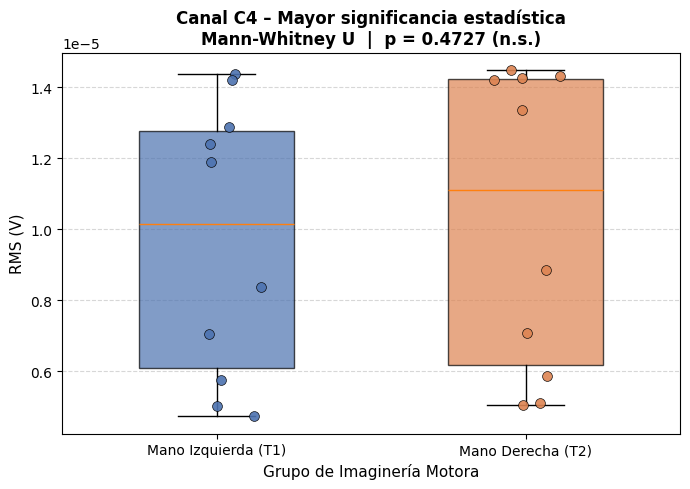

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

resultados = []

for canal in canales_ref:
    g_izq = df_izquierda[canal].dropna().values
    g_der = df_derecha[canal].dropna().values

    # 1. Shapiro-Wilk
    _, p_sw_izq = stats.shapiro(g_izq)
    _, p_sw_der = stats.shapiro(g_der)
    normalidad  = (p_sw_izq > 0.05) and (p_sw_der > 0.05)

    # 2. Levene
    _, p_lev         = stats.levene(g_izq, g_der)
    homocedasticidad = p_lev > 0.05

    # 3. Prueba de hipótesis
    if normalidad and homocedasticidad:
        _, p_val = stats.ttest_ind(g_izq, g_der, equal_var=True)
        prueba   = 't-Student'
    elif normalidad and not homocedasticidad:
        _, p_val = stats.ttest_ind(g_izq, g_der, equal_var=False)
        prueba   = 't-Welch'
    else:
        _, p_val = stats.mannwhitneyu(g_izq, g_der, alternative='two-sided')
        prueba   = 'Mann-Whitney U'


    resultados.append({
        'Canal'            : canal,
        'p_Shapiro_Izq'    : round(p_sw_izq, 4),
        'p_Shapiro_Der'    : round(p_sw_der, 4),
        'Normalidad'       : normalidad,
        'p_Levene'         : round(p_lev, 4),
        'Homocedasticidad' : homocedasticidad,
        'Prueba_usada'     : prueba,
        'p_valor'          : round(p_val, 4),
        'Significativo'    : p_val < 0.05
    })

df_resultados = pd.DataFrame(resultados).sort_values('p_valor').reset_index(drop=True)

# Tabla completa
pd.set_option('display.max_rows', 70)
pd.set_option('display.width', 130)
print('═' * 95)
print('RESULTADOS DEL ANÁLISIS ESTADÍSTICO – TODOS LOS CANALES ')
print('═' * 95)
print(df_resultados.to_string(index=False))

print('\n── Top 10 canales con menor p-valor ──')
print(df_resultados.head(10)[['Canal', 'p_valor', 'Prueba_usada']].to_string(index=False))

# Resumen canales significativos
df_sig = df_resultados[df_resultados['Significativo']]
print(f'\n Canales con diferencia estadística significativa (p < 0.05): {len(df_sig)}')
if len(df_sig) > 0:
    for _, row in df_sig.iterrows():
        print(f" ------> {row['Canal']:8s}  p = {row['p_valor']:.4f}  ({row['Prueba_usada']}) <--------")
else:
    print(' >>>>>>>>>>>>>>> Ninguno alcanzó significancia estadística.<<<<<<<<<<<<<<<<<<')

#Boxplot del canal más significativo (menor p-valor)
canal_top  = df_resultados.iloc[0]['Canal']
p_top      = df_resultados.iloc[0]['p_valor']
prueba_top = df_resultados.iloc[0]['Prueba_usada']

datos_izq = df_izquierda[canal_top].dropna().values
datos_der = df_derecha[canal_top].dropna().values

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(
    [datos_izq, datos_der],
    labels=['Mano Izquierda (T1)', 'Mano Derecha (T2)'],
    patch_artist=True, widths=0.5
)
colores = ['#4C72B0', '#DD8452']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, grupo in enumerate([datos_izq, datos_der], start=1):
    ax.scatter(
        np.random.normal(i, 0.05, size=len(grupo)),
        grupo, color=colores[i-1], alpha=0.9,
        s=50, zorder=3, edgecolors='k', linewidths=0.5
    )

sig_str = f'p = {p_top}' + (' *' if p_top < 0.05 else ' (n.s.)')
ax.set_title(
    f'Canal {canal_top} – Mayor significancia estadística\n'
    f'{prueba_top}  |  {sig_str}',
    fontsize=12, fontweight='bold'
)
ax.set_ylabel('RMS (V)', fontsize=11)
ax.set_xlabel('Grupo de Imaginería Motora', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




Al obtener los resultados , podemos observar que al usar las pruebas estadísticas t de Student,
T de Welch, y Mann-Whitney U no se obtuvo ningún canal significativo. Pero al canal C4 se le atribuye la mayor significancia estadística, el cual es consistente con la literatura anteriormente mencionada, ya que confirma que la zona central del cuero cabelludo (donde están C3 y C4) es la que más diferencia tiene entre las dos clases.


 No obstante la significancia estadística no se alcanza. Una de las razones principales es porque en este experimento se realizan las pruebas para un mismo sujeto con 2 condiciones (izq o der). Por consiguiente lo relevante en este estudio es comparar dentro de cada sujeto , el cómo cambia entre izquierda vs derecha. Sin embargo, se emplearon pruebas estadísticas para muestras independientes como la t de student y  Mann-Whitney U , ignorando el hecho de que ambas condiciones provienen del mismo sujeto, A esto se suma el reducido número de sujetos, hace que la prueba tenga poca capacidad para detectar diferencias reales entre condiciones, lo que significa que aunque exista una diferencia real entre las condiciones T1 y T2, el análisis no dispone de suficiente evidencia para declararla significativa. En general, se recomienda contar con al menos 20 a 30 sujetos para detectar diferencias entre condiciones de imaginación motora con una confianza razonable (Button et al., 2013).






Por otro lado , según la literatura hay pruebas más adecuadas para este tipo de estudios que involucran medidas repetidas del mismo sujeto bajo dos condiciones (T1 y T2). Como la prueba de  Wilcoxon y t pareada, estas trabajan con la diferencia dentro del mismo sujeto, no con grupos separados.


═══════════════════════════════════════════════════════════════════════════════════════════════
RESULTADOS DEL ANÁLISIS ESTADÍSTICO – TODOS LOS CANALES (ordenados por p-valor)
═══════════════════════════════════════════════════════════════════════════════════════════════
Canal  p_Shapiro_Izq  p_Shapiro_Der  Normalidad  p_Levene  Homocedasticidad Prueba_usada  p_valor  Significativo
   C4         0.1127         0.0128       False    0.5453              True     Wilcoxon   0.0020           True
  CP6         0.3893         0.0960        True    0.9081              True    t pareada   0.0117           True
  CP4         0.0683         0.0721        True    0.6031              True    t pareada   0.0248           True
   P6         0.1116         0.2251        True    0.9705              True    t pareada   0.0371           True
  TP8         0.2875         0.2925        True    0.9588              True    t pareada   0.0427           True
   C6         0.9494         0.7970        True   

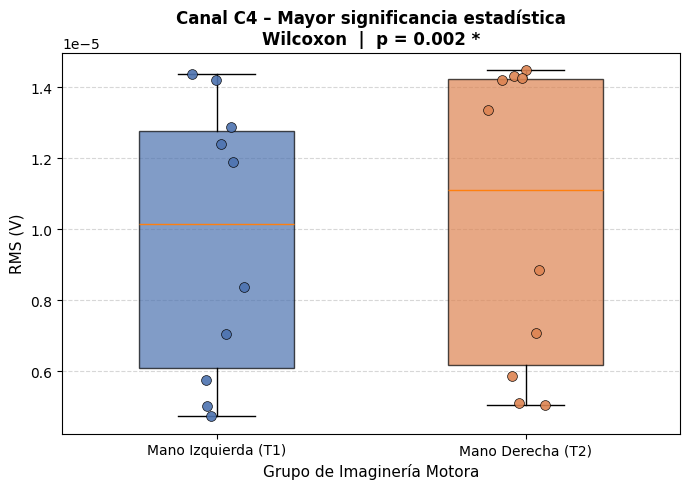

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

resultados = []

for canal in canales_ref:
    g_izq = df_izquierda[canal].dropna().values
    g_der = df_derecha[canal].dropna().values

    # 1. Shapiro-Wilk
    _, p_sw_izq = stats.shapiro(g_izq)
    _, p_sw_der = stats.shapiro(g_der)
    normalidad  = (p_sw_izq > 0.05) and (p_sw_der > 0.05)

    # 2. Levene
    _, p_lev         = stats.levene(g_izq, g_der)
    homocedasticidad = p_lev > 0.05

#CORREGIDOOOOOOOOO
    # 3. Prueb de hiptesisv --> estadisticas
    if normalidad:
        _, p_val = stats.ttest_rel(g_izq, g_der)
        prueba   = 't pareada'
    else:
        _, p_val = stats.wilcoxon(g_izq, g_der)
        prueba   = 'Wilcoxon'



    resultados.append({
        'Canal'            : canal,
        'p_Shapiro_Izq'    : round(p_sw_izq, 4),
        'p_Shapiro_Der'    : round(p_sw_der, 4),
        'Normalidad'       : normalidad,
        'p_Levene'         : round(p_lev, 4),
        'Homocedasticidad' : homocedasticidad,
        'Prueba_usada'     : prueba,
        'p_valor'          : round(p_val, 4),
        'Significativo'    : p_val < 0.05
    })

df_resultados = pd.DataFrame(resultados).sort_values('p_valor').reset_index(drop=True)

# Tabla completa
pd.set_option('display.max_rows', 70)
pd.set_option('display.width', 130)
print('═' * 95)
print('RESULTADOS DEL ANÁLISIS ESTADÍSTICO – TODOS LOS CANALES (ordenados por p-valor)')
print('═' * 95)
print(df_resultados.to_string(index=False))

print('\n── Top 10 canales con menor p-valor ──')
print(df_resultados.head(10)[['Canal', 'p_valor', 'Prueba_usada']].to_string(index=False))

# Resumen canales significativos
df_sig = df_resultados[df_resultados['Significativo']]
print(f'\nCanales con diferencia estadística significativa (p < 0.05): {len(df_sig)}')
if len(df_sig) > 0:
    for _, row in df_sig.iterrows():
        print(f" ----------------------> {row['Canal']:8s}  p = {row['p_valor']:.4f}  ({row['Prueba_usada']}) <----------------------")
else:
    print(' <<<<<<<<<<<<<<<<<<< Ninguno alcanzó significancia estadística.>>>>>>>>>>>>>>>>>>>>>>>>>')

# ── Boxplot del canal más significativo (menor p-valor) ──────────────────────
canal_top  = df_resultados.iloc[0]['Canal']
p_top      = df_resultados.iloc[0]['p_valor']
prueba_top = df_resultados.iloc[0]['Prueba_usada']

datos_izq = df_izquierda[canal_top].dropna().values
datos_der = df_derecha[canal_top].dropna().values

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(
    [datos_izq, datos_der],
    labels=['Mano Izquierda (T1)', 'Mano Derecha (T2)'],
    patch_artist=True, widths=0.5
)
colores = ['#4C72B0', '#DD8452']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, grupo in enumerate([datos_izq, datos_der], start=1):
    ax.scatter(
        np.random.normal(i, 0.05, size=len(grupo)),
        grupo, color=colores[i-1], alpha=0.9,
        s=50, zorder=3, edgecolors='k', linewidths=0.5
    )

sig_str = f'p = {p_top}' + (' *' if p_top < 0.05 else ' (n.s.)')
ax.set_title(
    f'Canal {canal_top} – Mayor significancia estadística\n'
    f'{prueba_top}  |  {sig_str}',
    fontsize=12, fontweight='bold'
)
ax.set_ylabel('RMS (V)', fontsize=11)
ax.set_xlabel('Grupo de Imaginería Motora', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()






En este caso podemos evidenciar que el sistema arrojó canales significativos, ya que con estas pruebas se logra eliminar la variabilidad entre sujetos, esto se explica porque estas pruebas están diseñadas específicamente para diseños de medidas repetidas, donde los mismos sujetos son evaluados bajos dos condiciones diferentes, comparando directamente el cambio dentro de cada sujeto en lugar de tratarlos como independientes. Resumidamente el test en vez de comparar los grupos, el test calcula la diferencia para cada sujeto individualmente (Lee, 2022).


Finalmente podemos decir que la mejor opción en este caso es usar pruebas pareadas como se demuestra en la literatura, donde estudios realizan la comparación de estudios de EEG de la desincronización relacionada con eventos (ERD) entre los canales C3 y C4 para las condiciones de mano izquierda y derecha se realiza mediante prueba t pareada, dado que los mismos sujetos son evaluados bajo ambas condiciones. (Cho et al., 2017)


**REFERENCIAS**

1. Saibene, A., Caglioni, M., Corchs, S., & Gasparini, F. (2023). EEG-Based BCIs on Motor Imagery Paradigm Using Wearable Technologies: A Systematic Review. Sensors, 23(5), 2798. https://doi.org/10.3390/s23052798
2. Singh, A., Hussain, A. A., Lal, S., & Guesgen, H. W. (2021). A Comprehensive Review on Critical Issues and Possible Solutions of Motor Imagery Based Electroencephalography Brain-Computer Interface. Sensors (Basel, Switzerland), 21(6), 2173. https://doi.org/10.3390/s21062173
3. Marper, S. (s. f.). Ondas mu actividad motora: ritmo motor y control del movimiento. https://ondasbinaurales.com/blog/articulos/ondas-mu-actividad-motora.html
4. Fisiología de la actividad eléctrica del cerebro: electroencefalografía | FISIOLOGÍA. (s. f.). https://fisiologia.facmed.unam.mx/index.php/fisiologia-de-la-actividad-electrica-del-cerebro-electroencefalografia/
5. Varabilidad inter e intra-sujeto en EEG: Una encuesta sistemática. (s. f.). https://www.q2bstudio.com/nuestro-blog/598024/descubre-la-variabilidad-inter-e-intra-sujeto-en-eeg-con-esta-encuesta-detallada-conoce-las-diferencias-y-similitudes-en-la-actividad-cerebral-para-una-mejor-comprension-de-la-investigacion-en-neurociencia?scriptscookies=1
6. Pfurtscheller, G., Brunner, C., Schlögl, A., & Lopes da Silva, F. H. (2006). Mu rhythm (de)synchronization and EEG single-trial classification of different motor imagery tasks. NeuroImage, 31(1), 153–159. https://doi.org/10.1016/j.neuroimage.2005.12.003
7. Button, K. S., Ioannidis, J. P., Mokrysz, C., Nosek, B. A., Flint, J., Robinson, E. S., & Munafò, M. R. (2013). Power failure: why small sample size undermines the reliability of neuroscience. Nature reviews. Neuroscience, 14(5), 365–376. https://doi.org/10.1038/nrn3475
8. Cho, H., Ahn, M., Ahn, S., Kwon, M., & Jun, S. C. (2017). EEG datasets for motor imagery brain–computer interface. GigaScience, 6(7), 1-8. https://doi.org/10.1093/gigascience/gix034
9. Lee, S. W. (2022). Methods for testing statistical differences between groups in medical research: Statistical standard and guideline of Life Cycle Committee. Life Cycle, 2, e1. https://doi.org/10.54724/lc.2022.e1
